<a href="https://colab.research.google.com/github/aditya030604-collab/MS_Elevate_Internship_Project/blob/main/top50_India.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# AI-Based Music Trend and Sentiment Analysis System
# Install required libraries
!pip install textblob

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

In [ ]:
# Upload Dataset
from google.colab import files
uploaded = files.upload()

# Load the dataset
df = pd.read_csv('spotify_top50_India_dataset.csv')

# Display first 5 rows
print("First 5 rows of dataset:")
print(df.head())

Saving spotify_top50_India_dataset.csv to spotify_top50_India_dataset (1).csv
First 5 rows of dataset:
                                          Track Name   Artist Name  \
0  Phir Aur Kya Chahiye (From "Zara Hatke Zara Ba...  Sachin-Jigar   
1       O Bedardeya (From "Tu Jhoothi Main Makkaar")        Pritam   
2                                     Maan Meri Jaan          King   
3                                           Kesariya        Pritam   
4                                           Obsessed     Riar Saab   

                                          Album Name  Duration (ms)  \
0  Phir Aur Kya Chahiye (From "Zara Hatke Zara Ba...         266075   
1       O Bedardeya (From "Tu Jhoothi Main Makkaar")         313051   
2                                     Champagne Talk         194653   
3    Brahmastra (Original Motion Picture Soundtrack)         268164   
4                                           Obsessed         190444   

   Popularity  
0          76  
1          85  
2

In [ ]:
# Basic Dataset Info
print("\nDataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

NameError: name 'df' is not defined

In [ ]:
# Data Cleaning
# Remove duplicates
df = df.drop_duplicates()

# Drop rows with missing values (if any)
df = df.dropna()

# Convert duration from ms to minutes
df['Duration_Minutes'] = df['Duration (ms)'] / 60000

In [ ]:
# Optional Sentiment Analysis (Based on Track Name)
def get_sentiment(text):
    analysis = TextBlob(str(text))
    score = analysis.sentiment.polarity
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Track Name'].apply(get_sentiment)

In [ ]:
# Trend Analysis
# Top 10 most popular tracks
top_tracks = df.sort_values(by='Popularity', ascending=False).head(10)
print("\nTop 10 Most Popular Tracks:")
print(top_tracks[['Track Name', 'Artist Name', 'Popularity']])

# Top artists by average popularity
artist_popularity = df.groupby('Artist Name')['Popularity'].mean().sort_values(ascending=False).head(10)
print("\nTop 10 Artists by Average Popularity:")
print(artist_popularity)


Top 10 Most Popular Tracks:
                                      Track Name      Artist Name  Popularity
23                             Cupid - Twin Ver.      FIFTY FIFTY          98
33                                       Starboy       The Weeknd          93
38                                        People         Libianca          93
49                                         Bones  Imagine Dragons          87
2                                 Maan Meri Jaan             King          86
1   O Bedardeya (From "Tu Jhoothi Main Makkaar")           Pritam          85
6                                Kahani Suno 2.0     Kaifi Khalil          85
12                             Jhoome Jo Pathaan   Vishal-Shekhar          84
7                                   Malang Sajna    Sachet Tandon          84
9                                Tere Pyaar Mein           Pritam          84

Top 10 Artists by Average Popularity:
Artist Name
FIFTY FIFTY        98.0
Libianca           93.0
The Weeknd    

/tmp/ipykernel_7823/217518388.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Popularity', y='Track Name', data=top_tracks, palette='viridis')


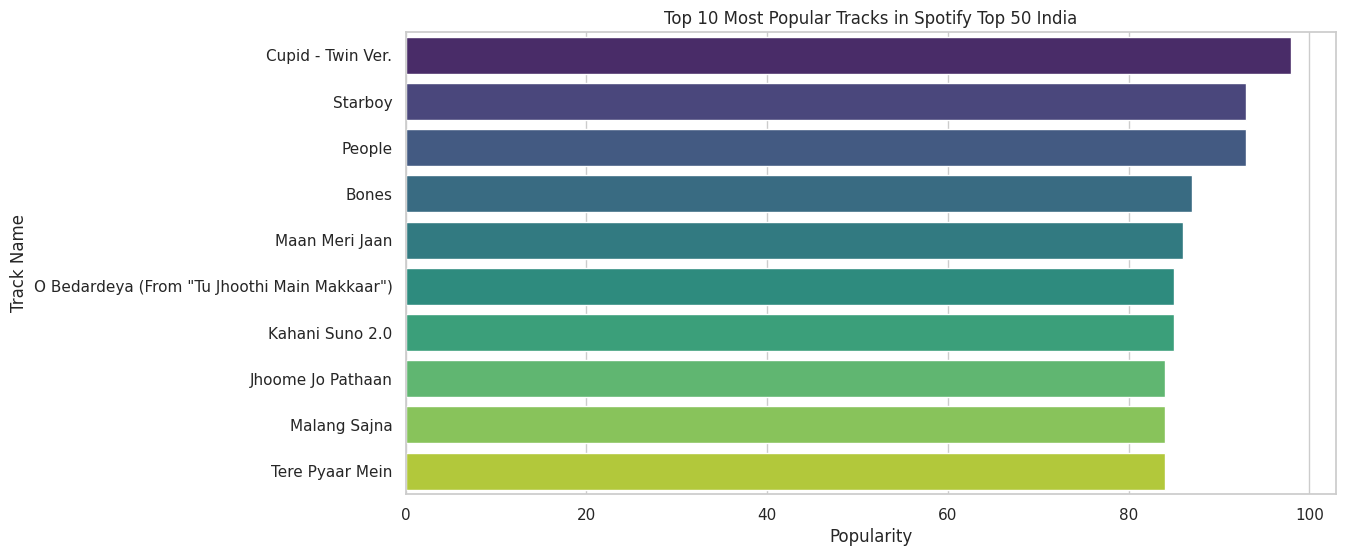

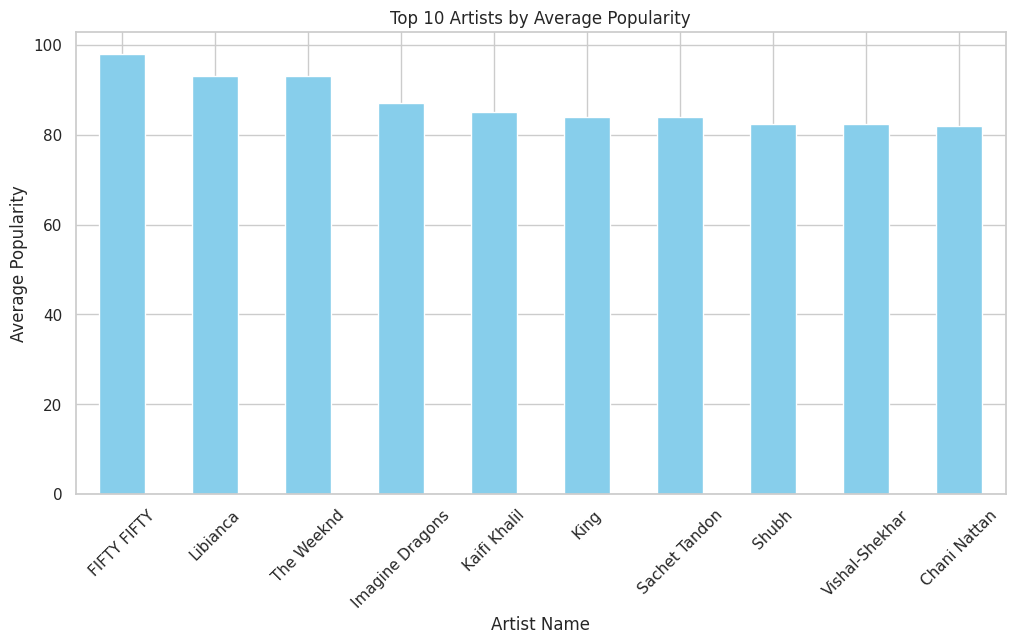

/tmp/ipykernel_7823/217518388.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='coolwarm')


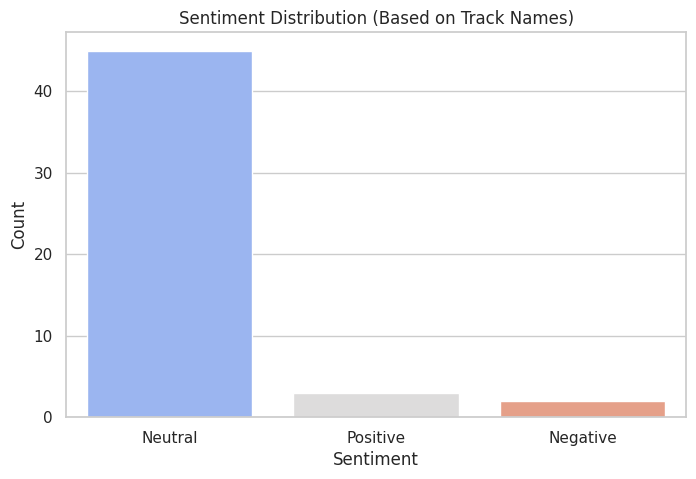

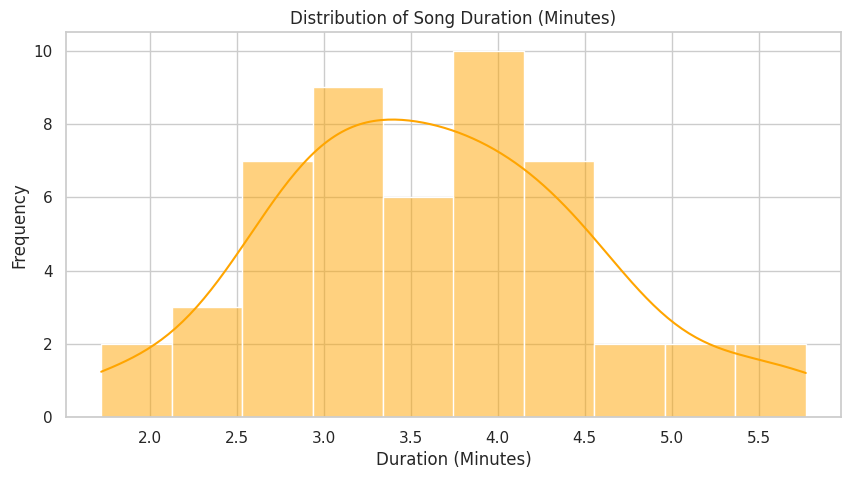

In [ ]:
# Visualizations
sns.set(style="whitegrid")

# 1. Top 10 Tracks by Popularity
plt.figure(figsize=(12,6))
sns.barplot(x='Popularity', y='Track Name', data=top_tracks, palette='viridis')
plt.title('Top 10 Most Popular Tracks in Spotify Top 50 India')
plt.xlabel('Popularity')
plt.ylabel('Track Name')
plt.show()

# 2. Top 10 Artists by Average Popularity
plt.figure(figsize=(12,6))
artist_popularity.plot(kind='bar', color='skyblue')
plt.title('Top 10 Artists by Average Popularity')
plt.xlabel('Artist Name')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45)
plt.show()

# 3. Sentiment Distribution (Track Name Based)
plt.figure(figsize=(8,5))
sns.countplot(x='Sentiment', data=df, palette='coolwarm')
plt.title('Sentiment Distribution (Based on Track Names)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# 4. Duration Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Duration_Minutes'], bins=10, kde=True, color='orange')
plt.title('Distribution of Song Duration (Minutes)')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Save Processed File for Power BI
df.to_csv('spotify_top50_India_processed.csv', index=False)
print("\nProcessed file saved as: spotify_top50_India_processed.csv")

# Download the processed file
files.download('spotify_top50_India_processed.csv')


Processed file saved as: spotify_top50_India_processed.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>